Felix Shyann 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')

df



,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [2]:
df = df.drop_duplicates(keep='first')

In [3]:
df.shape

(229781, 22)

In [4]:
categorical_columns = ['Age']

diabetes_encoded = pd.get_dummies(df, columns=categorical_columns, dtype=float, drop_first=True)

diabetes_encoded.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,Age_4.0,Age_5.0,Age_6.0,Age_7.0,Age_8.0,Age_9.0,Age_10.0,Age_11.0,Age_12.0,Age_13.0
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [5]:
diabetes_encoded.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Education               0
Income                  0
Age_2.0                 0
Age_3.0                 0
Age_4.0                 0
Age_5.0                 0
Age_6.0                 0
Age_7.0                 0
Age_8.0                 0
Age_9.0                 0
Age_10.0                0
Age_11.0                0
Age_12.0                0
Age_13.0                0
dtype: int64

In [6]:
age_dummy_cols = [col for col in diabetes_encoded.columns if col.startswith('Age_')]
predictors = ['Smoker', 'BMI', 'PhysActivity', 'HighBP', 'HighChol'] + age_dummy_cols

X_diabetes = diabetes_encoded[predictors]
y_diabetes = diabetes_encoded['Diabetes_012']

In [7]:
#Standardize the features using StandardScaler 
scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

X_diabetes_scaled

array([[ 1.07120772,  1.6672198 , -1.65840343, ..., -0.32572837,
        -0.26796404, -0.28097354],
       [ 1.07120772, -0.54310088,  0.60298959, ..., -0.32572837,
        -0.26796404, -0.28097354],
       [-0.93352576, -0.10103675, -1.65840343, ..., -0.32572837,
        -0.26796404, -0.28097354],
       ...,
       [-0.93352576, -0.10103675,  0.60298959, ..., -0.32572837,
        -0.26796404, -0.28097354],
       [-0.93352576, -0.83781031, -1.65840343, ..., -0.32572837,
        -0.26796404, -0.28097354],
       [-0.93352576, -0.54310088,  0.60298959, ..., -0.32572837,
        -0.26796404, -0.28097354]])

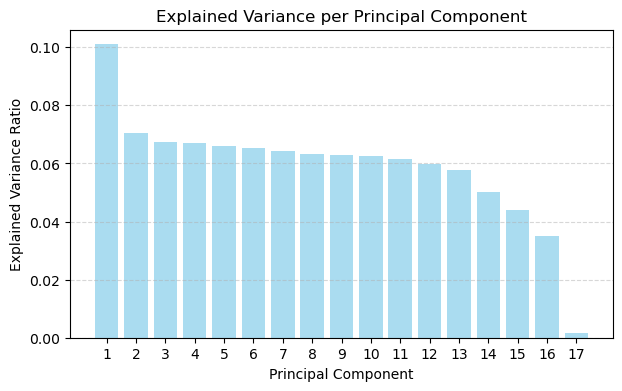

In [8]:
#Fit PCA to the standardized features and plot the explained variance ratio for each(atleast 90%)
pca = PCA()
X_pca = pca.fit_transform(X_diabetes_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(7, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.7, color='skyblue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()

In [9]:
#https://stackoverflow.com/questions/76552607/getting-pca-explained-variance-ratio-for-all-components-without-doing-pca-twice
print(explained_variance_ratio)

[0.10098008 0.07043536 0.06749512 0.06703214 0.06594851 0.06526933
 0.06440173 0.06329512 0.0629416  0.06240071 0.06151658 0.05980518
 0.05780723 0.05007214 0.04397181 0.03511614 0.00151122]


In [10]:
pca = PCA(n_components=14)
X_pca_3d = pca.fit_transform(X_diabetes_scaled)

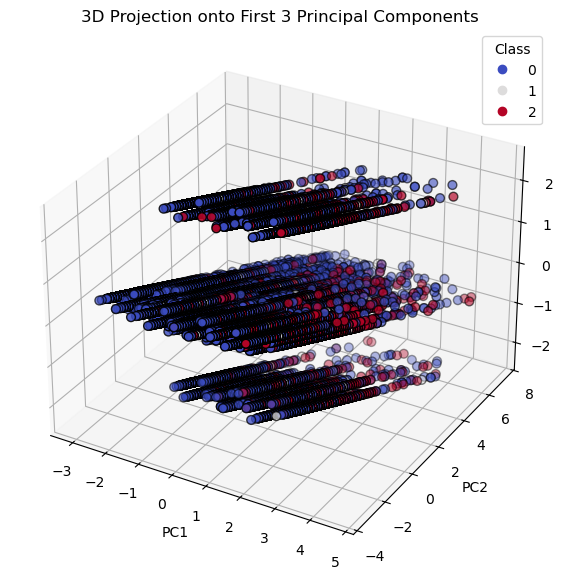

In [11]:
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# You can color by known labels or by clusters if you’ve run KMeans
scatter = ax.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=y_diabetes,  # or use cluster_labels
    cmap='coolwarm', edgecolor='k', s=40
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D Projection onto First 3 Principal Components')
plt.legend(*scatter.legend_elements(), title="Class")
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score

X_train, X_test, y_train, y_test = train_test_split(X_pca_3d, y_diabetes, test_size=0.2)

log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

In [13]:
X_train

array([[-0.32331249,  0.97697224,  0.00846586, ...,  0.08201455,
         0.39079021, -0.85940739],
       [ 0.06594808,  1.5786715 , -0.01309496, ...,  0.35380479,
         0.38024667, -0.74522799],
       [ 1.18558145, -2.11040965,  0.45638864, ...,  0.31998746,
        -1.46581967,  0.95826297],
       ...,
       [ 0.50087147,  0.31916864, -0.10696395, ..., -0.67823781,
        -1.32147085,  0.08730408],
       [-1.75686261,  0.35667239, -0.24257674, ...,  0.88677116,
         0.13637382,  1.58424858],
       [-2.40512391, -0.47925173, -0.08311693, ..., -0.1639571 ,
        -1.36394843, -0.22172086]])

In [14]:
f1_scores_logreg = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='f1_weighted')

print("Logistic Regression - F1 Scores across folds:", f1_scores_logreg)
print("Logistic Regression - Mean F1 Score:", f1_scores_logreg.mean())

Logistic Regression - F1 Scores across folds: [0.76653081 0.7685794  0.76585185 0.76664184 0.76744298]
Logistic Regression - Mean F1 Score: 0.7670093775892639


In [15]:
accuracy_scores_logreg = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')

print("Logistic Regression - Accuracy Scores across folds:", accuracy_scores_logreg)
print("Logistic Regression - Mean Accuracy:", accuracy_scores_logreg.mean())

Logistic Regression - Accuracy Scores across folds: [0.82787978 0.82918537 0.82779818 0.82820617 0.82915352]
Logistic Regression - Mean Accuracy: 0.8284446030383231


In [16]:
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred, average='weighted')  # Weighted for multi-class

print("Test Accuracy: " + str(test_accuracy))
print("Test F1 Score: " + str(test_f1))

Test Accuracy: 0.8299497356224297
Test F1 Score: 0.7692162568133187


In [17]:
X = df.drop('Diabetes_012', axis=1)

scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(X)

X_scaled

array([[ 1.09567501,  1.12413247,  0.20535591, ...,  0.29524111,
        -0.98758781, -1.38132379],
       [-0.91267939, -0.88957488, -4.86959434, ..., -0.35121265,
         1.0267291 , -2.33713069],
       [ 1.09567501,  1.12413247,  0.20535591, ...,  0.29524111,
        -0.98758781,  1.00819343],
       ...,
       [-0.91267939, -0.88957488,  0.20535591, ..., -1.96734705,
         0.01957065, -1.85922724],
       [ 1.09567501, -0.88957488,  0.20535591, ..., -0.35121265,
         0.01957065, -2.33713069],
       [ 1.09567501,  1.12413247,  0.20535591, ...,  0.29524111,
         1.0267291 , -1.85922724]])

In [18]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

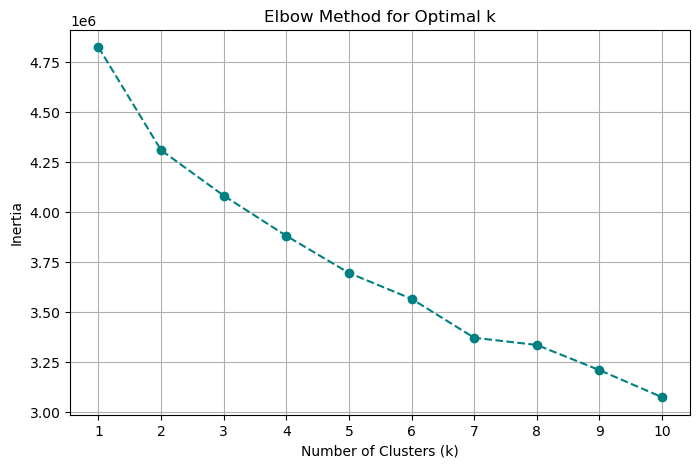

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [22]:
final_kmeans = KMeans(n_clusters=3,random_state=42)
cluster_labels = final_kmeans.fit_predict(X_scaled)

In [23]:
# Get cluster centers in standardized feature space
cluster_centers = final_kmeans.cluster_centers_

# Convert to a DataFrame for readability
centers_df = pd.DataFrame(cluster_centers, columns=X.columns)
centers_df

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.706281,0.425992,0.169285,0.087104,0.105195,-0.018729,0.108084,0.030942,0.024688,-0.003890,...,0.148397,-0.200574,-0.009277,-0.273198,-0.307937,-0.223575,0.147981,0.543465,-0.040441,0.051611
1,-0.775851,-0.489820,-0.179868,-0.232192,-0.208406,-0.188055,-0.311831,0.231972,0.043801,0.099768,...,-0.091913,-0.017039,-0.494398,-0.118044,-0.332879,-0.410982,-0.058369,-0.575509,0.257699,0.307996
2,0.449028,0.325172,0.092486,0.394605,0.297614,0.506545,0.548581,-0.641254,-0.160546,-0.239783,...,-0.082345,0.462357,1.248027,0.865438,1.472059,1.489487,-0.164830,0.292118,-0.555707,-0.873460


**Observations found in each cluster:**

Cluster 0: In cluster 0, highBP is listed as 0.71, HighCHol is 0.43, BMI is 0.09, Smoker is at 0.11, Stroke is at -0.02, HeartDiseaseorAttack is at 0.11, PhysicalActivity is at 0.03(close to average), Age is high in this cluster at 0.54, but education is -0.04... This cluster seems to show individuals who are older and have higher health risk factors(BP and Cholesterol).

Cluster 1: In cluster 1, HighBP is listed as -0.78, HighChol is -0.49, BMI is -0.23, Smoker is at -0.-0.21, Stroke is at -0.19, HeartDiseaseorAttack is at -0.31, PhysicalActivity is slightly above average at 0.23, GenHlth is -0.49, Education is 0.26, and Income is 0.31... In this cluster, important factors such as HighBP and HighChol show as below average, indicating a low risk for many of the bad health indicators. According to the Age column, this cluster represents individuals who are slightly younger.

Cluster 2: In cluster 2, HighBP is 0.45, HighChol is at 0.33, AnyHealthcare stands out the most to me as it is at -0.08(close to average), CholCheck is at 0.09, Age is at 0.29, Education is -0.56, and Income is -0.87... Based on observations, this cluster represents individuals with decent average healthcare, elevated BP and Cholesterol, and below average income and education.